# Playground Series S6E4 - 관개 필요량 예측 (EDA)

**목표:** `Irrigation_Need` (Low / Medium / High) 예측 - 3클래스 분류  
**평가지표:** Balanced Accuracy  
**Train:** 630,000행 / **Test:** 270,000행

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

NUM_COLS = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
            'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
            'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
CAT_COLS = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
            'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
TARGET = 'Irrigation_Need'

print(f"Train 크기: {train.shape}")
print(f"Test 크기:  {test.shape}")
print(f"\n결측치 (Train): {train.isnull().sum().sum()}")
print(f"결측치 (Test):  {test.isnull().sum().sum()}")
train.head()

Train 크기: (630000, 21)
Test 크기:  (270000, 20)

결측치 (Train): 0
결측치 (Test):  0


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


## 1. 타겟 분포

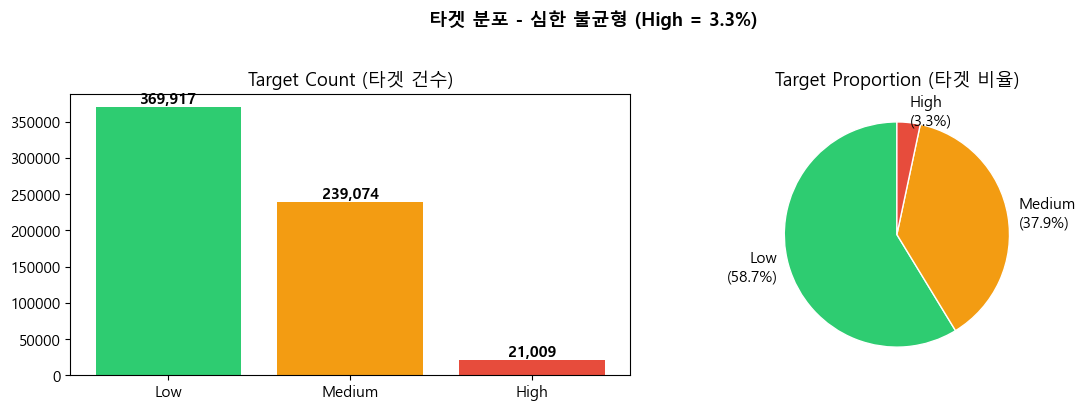

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = train[TARGET].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']

axes[0].bar(vc.index, vc.values, color=colors)
axes[0].set_title('Target Count (타겟 건수)')
for i, (idx, v) in enumerate(vc.items()):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

pct = vc / len(train) * 100
axes[1].pie(pct.values, labels=[f'{k}\n({v:.1f}%)' for k, v in pct.items()],
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Target Proportion (타겟 비율)')

plt.suptitle('타겟 분포 - 심한 불균형 (High = 3.3%)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. 수치형 피처 - 타겟별 분포

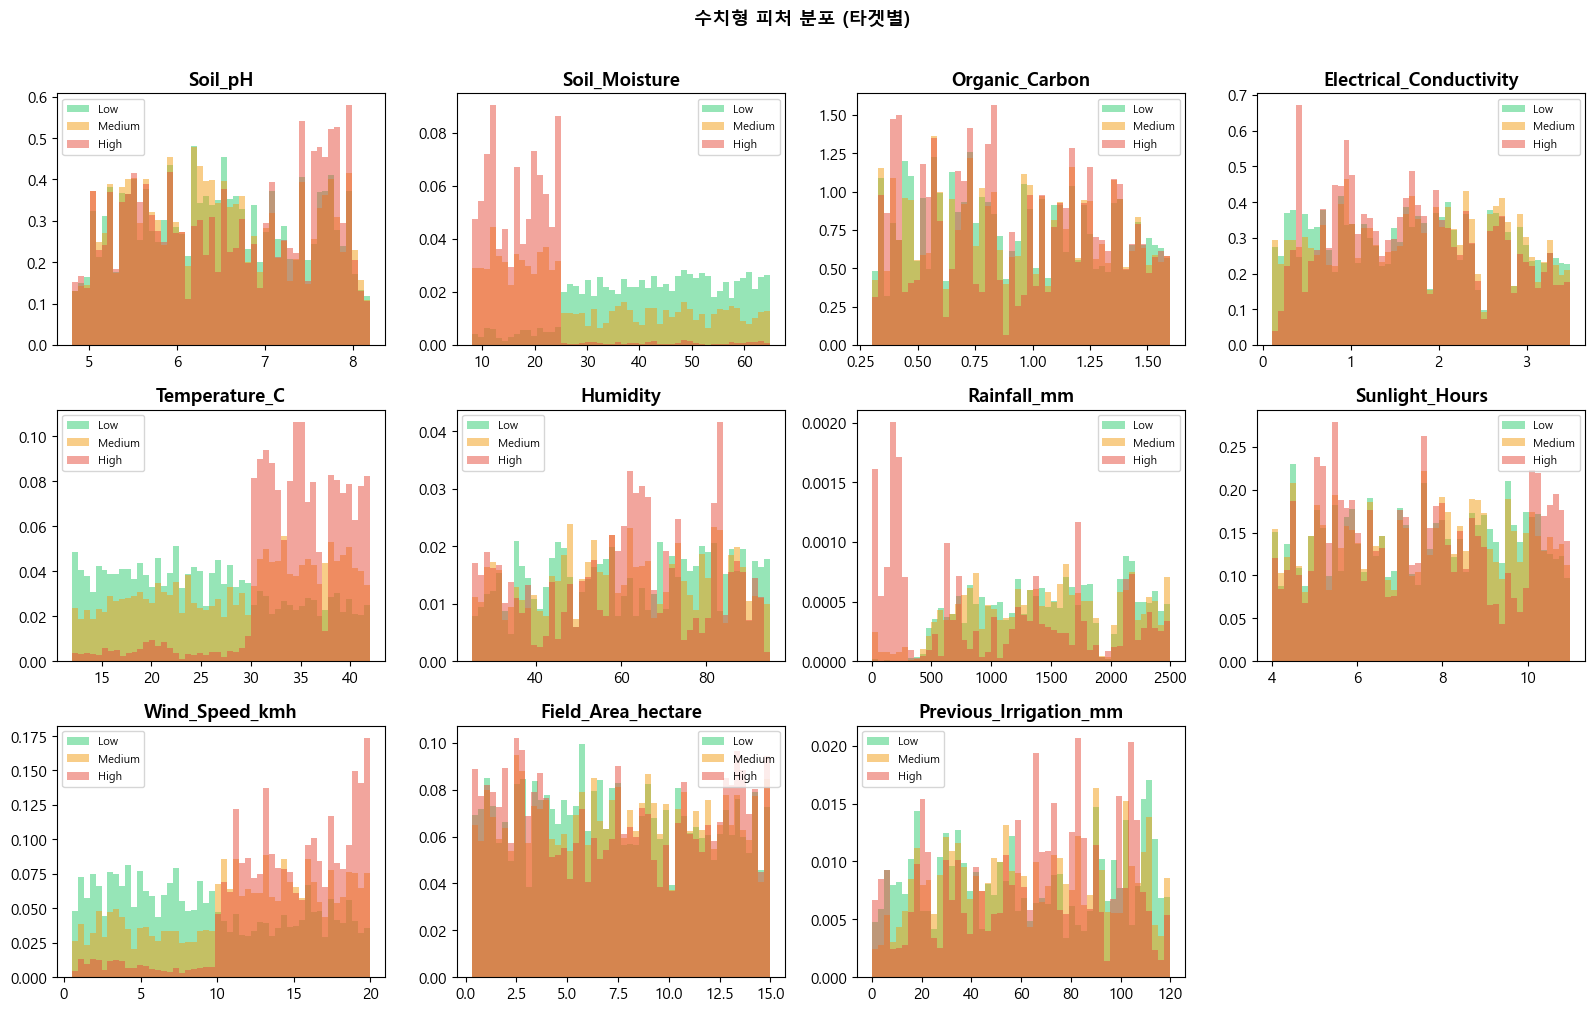

In [3]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
target_order = ['Low', 'Medium', 'High']
colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    for label in target_order:
        subset = train[train[TARGET] == label][col]
        ax.hist(subset, bins=50, alpha=0.5, label=label, color=colors[label], density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('수치형 피처 분포 (타겟별)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [4]:
# 타겟별 평균값 비교 + 판별력 지표
mean_by_target = train.groupby(TARGET)[NUM_COLS].mean().T
mean_by_target = mean_by_target[['Low', 'Medium', 'High']]
mean_by_target['High-Low 차이'] = mean_by_target['High'] - mean_by_target['Low']
mean_by_target['|차이|/표준편차'] = abs(mean_by_target['High-Low 차이']) / train[NUM_COLS].std()
mean_by_target = mean_by_target.sort_values('|차이|/표준편차', ascending=False).round(2)
mean_by_target.style.background_gradient(subset=['|차이|/표준편차'], cmap='YlOrRd')

Irrigation_Need,Low,Medium,High,High-Low 차이,|차이|/표준편차
Soil_Moisture,43.310000,29.740000,17.670000,-25.640000,1.570000
Temperature_C,25.350000,28.890000,34.570000,9.220000,1.070000
Wind_Speed_kmh,9.220000,11.790000,14.640000,5.430000,0.950000
Rainfall_mm,1500.530000,1444.480000,989.160000,-511.380000,0.830000
Soil_pH,6.490000,6.470000,6.580000,0.090000,0.100000
Electrical_Conductivity,1.730000,1.770000,1.690000,-0.040000,0.040000
Humidity,61.950000,61.000000,61.120000,-0.830000,0.040000
Previous_Irrigation_mm,61.720000,63.180000,63.050000,1.330000,0.040000
Sunlight_Hours,7.510000,7.520000,7.460000,-0.050000,0.020000
Field_Area_hectare,7.450000,7.630000,7.530000,0.080000,0.020000


## 3. 범주형 피처 vs 타겟

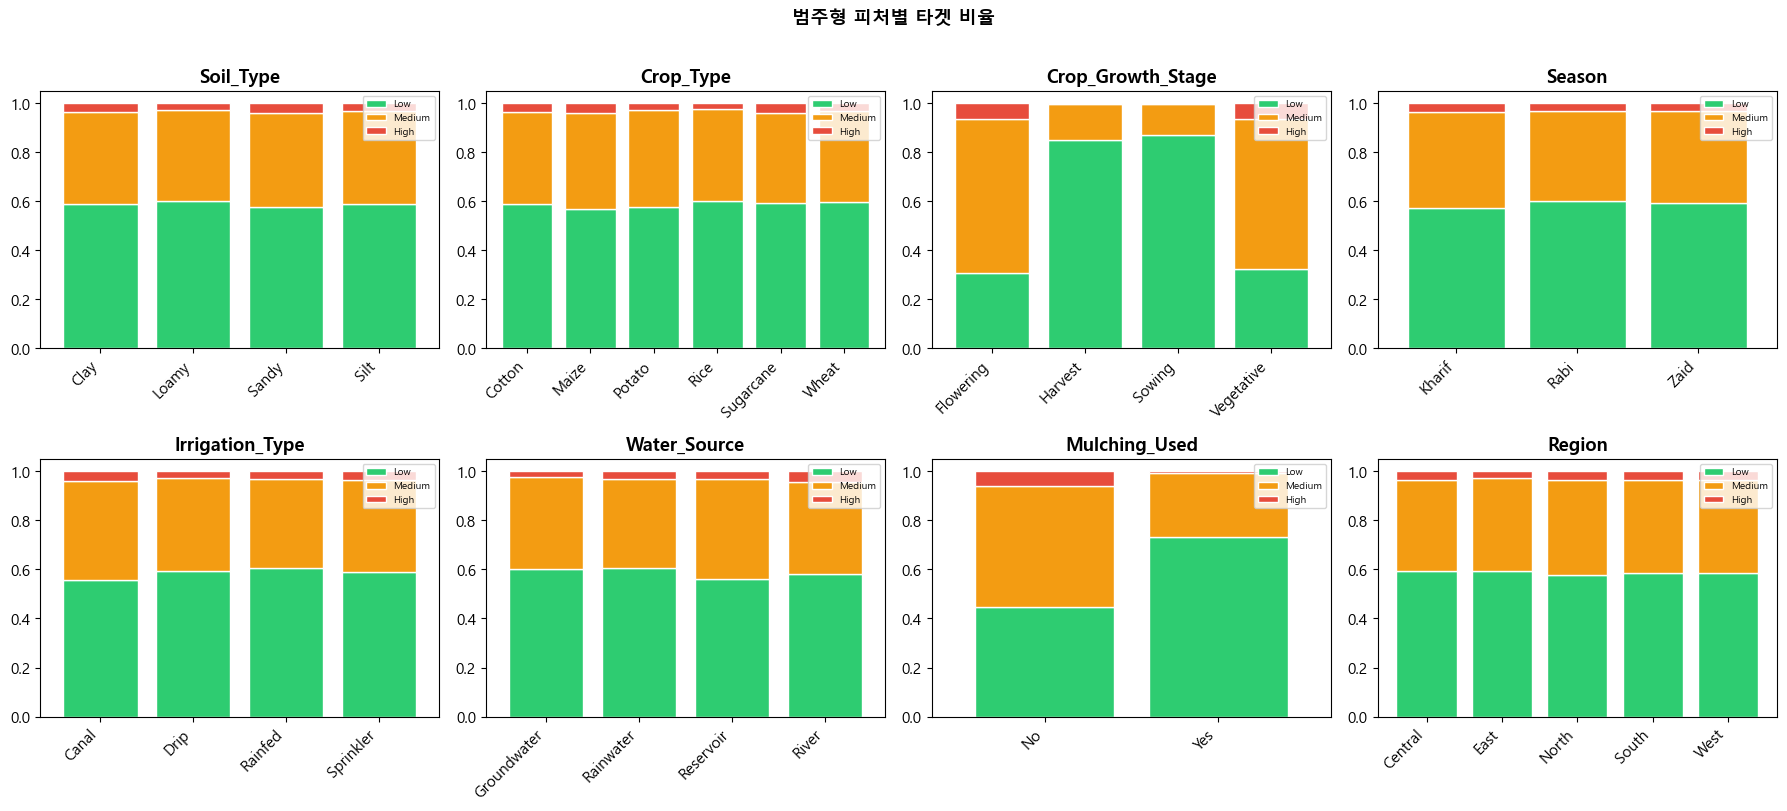

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
target_order = ['Low', 'Medium', 'High']

for i, col in enumerate(CAT_COLS):
    ax = axes[i]
    ct = pd.crosstab(train[col], train[TARGET], normalize='index')[target_order]
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#f39c12', '#e74c3c'],
            edgecolor='white', width=0.8)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_ylim(0, 1.05)

plt.suptitle('범주형 피처별 타겟 비율', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. 피처 간 상관관계

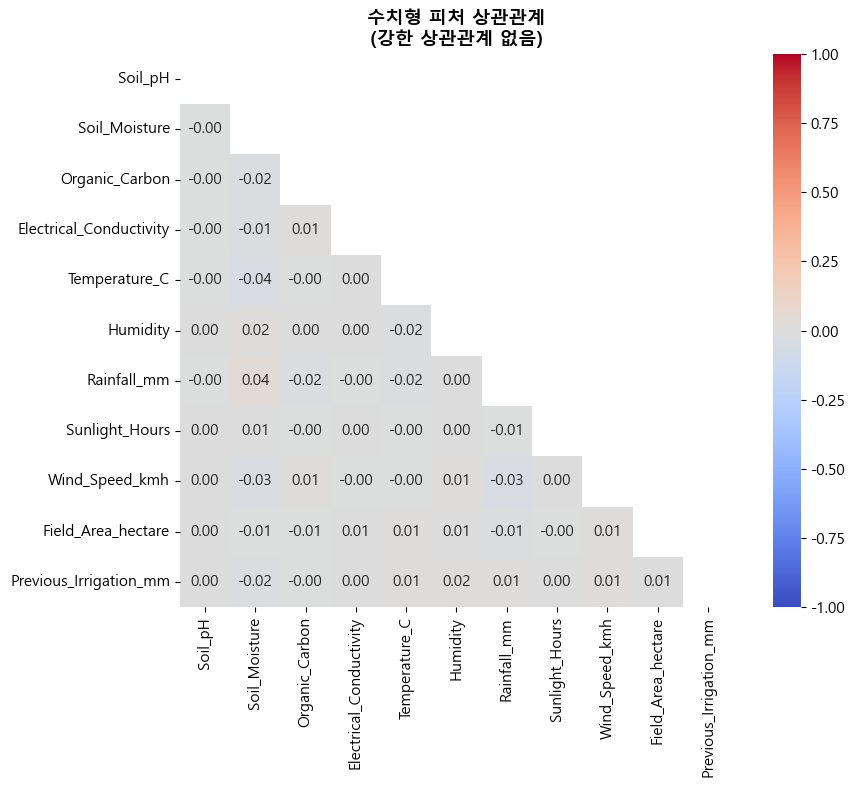

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = train[NUM_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('수치형 피처 상관관계\n(강한 상관관계 없음)', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Train vs Test 분포 비교

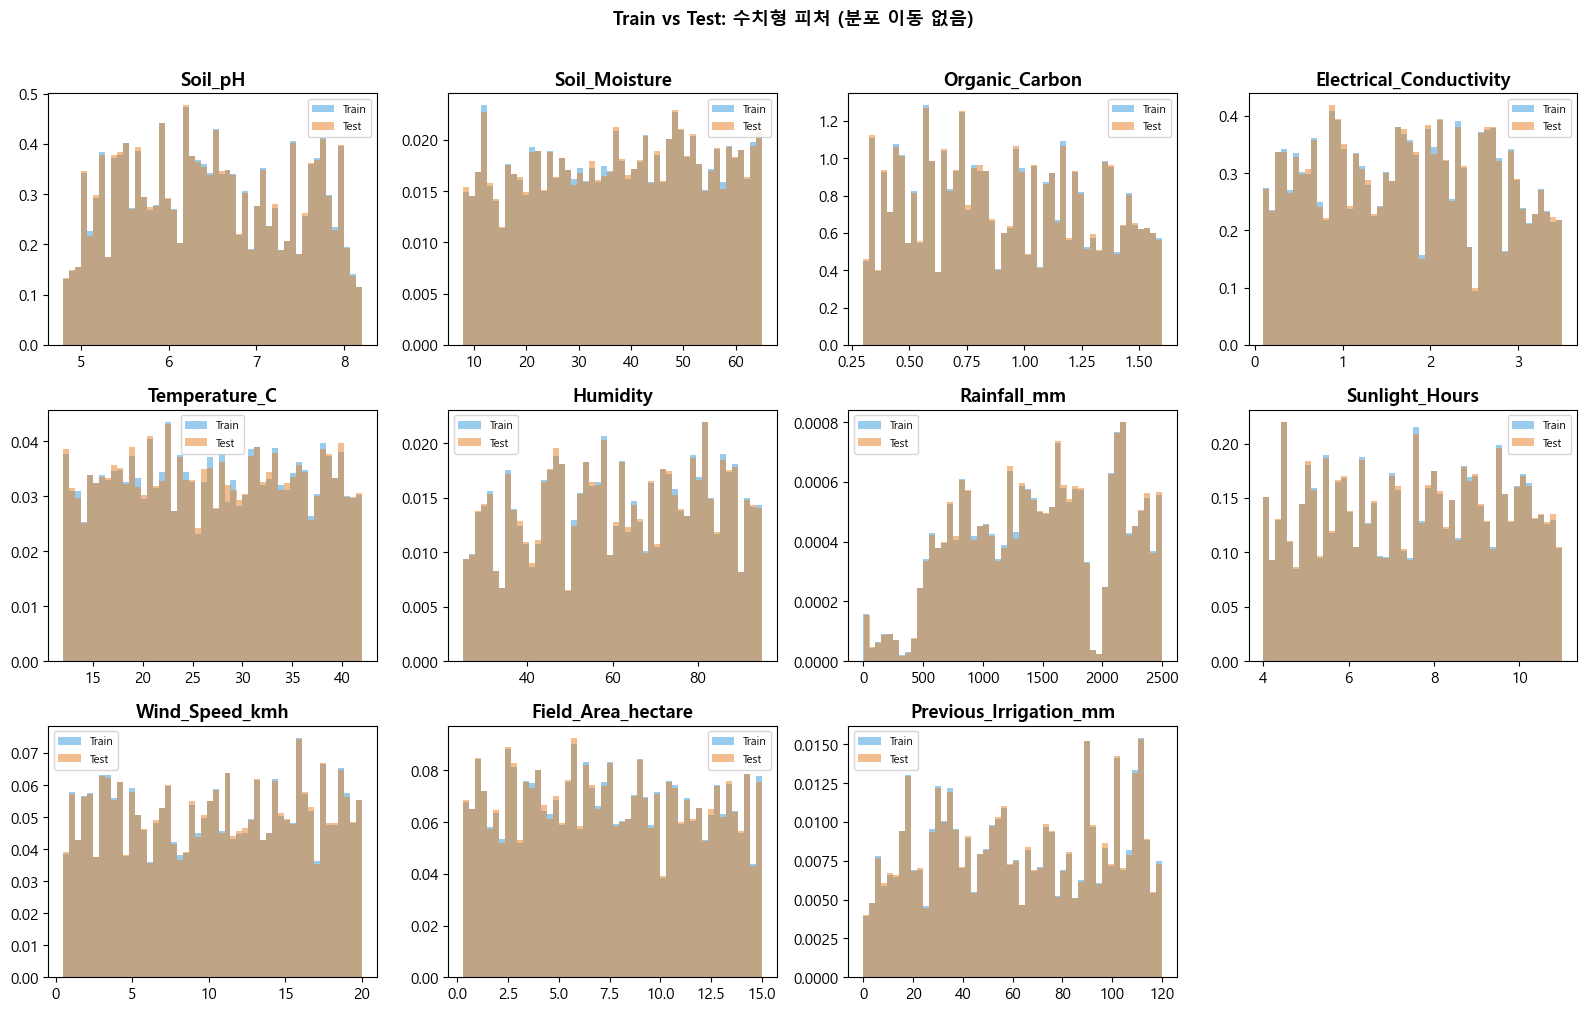

In [7]:
# 수치형 피처: Train vs Test
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    ax.hist(train[col], bins=50, alpha=0.5, label='Train', color='#3498db', density=True)
    ax.hist(test[col], bins=50, alpha=0.5, label='Test', color='#e67e22', density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Train vs Test: 수치형 피처 (분포 이동 없음)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

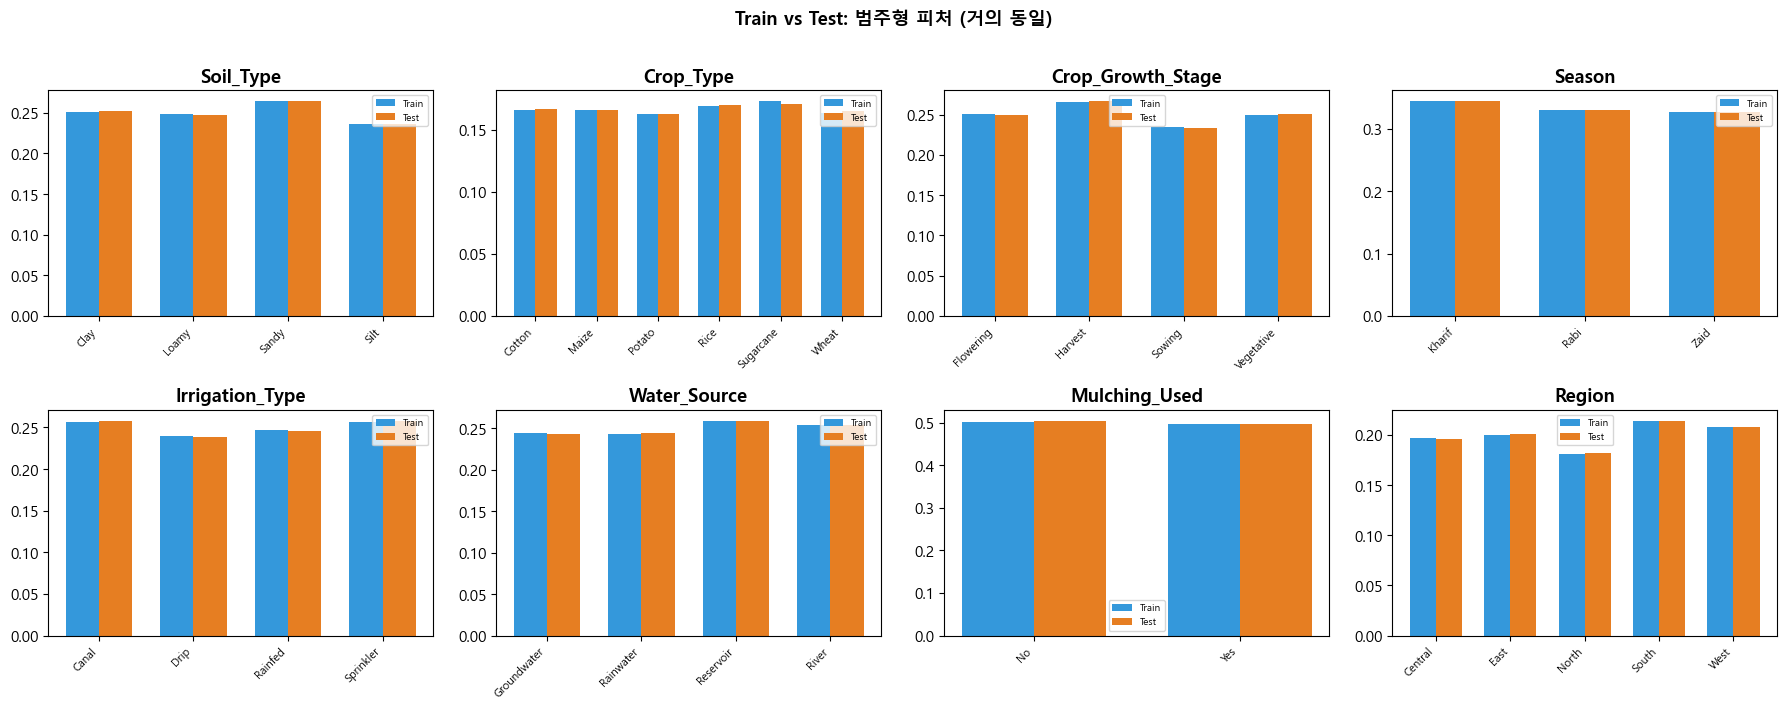

In [8]:
# 범주형 피처: Train vs Test
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    ax = axes[i]
    tr = train[col].value_counts(normalize=True).sort_index()
    te = test[col].value_counts(normalize=True).sort_index()
    x = np.arange(len(tr))
    w = 0.35
    ax.bar(x - w/2, tr.values, w, label='Train', color='#3498db')
    ax.bar(x + w/2, te.values, w, label='Test', color='#e67e22')
    ax.set_title(col, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(tr.index, rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle('Train vs Test: 범주형 피처 (거의 동일)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. 주요 피처 인터랙션

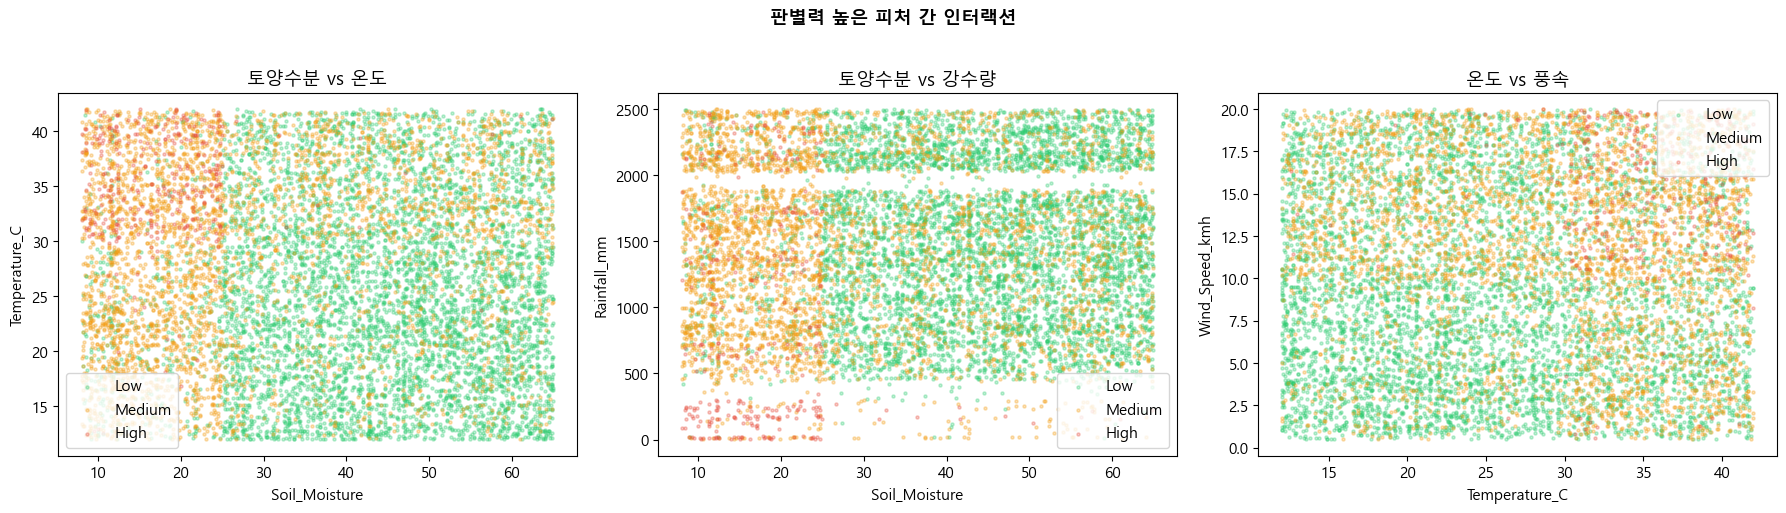

In [9]:
# 판별력 높은 피처 간 상호작용
sample = train.sample(10000, random_state=42)
color_map = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Soil_Moisture vs Temperature_C
for label in ['Low', 'Medium', 'High']:
    s = sample[sample[TARGET] == label]
    axes[0].scatter(s['Soil_Moisture'], s['Temperature_C'], alpha=0.3, s=5,
                    color=color_map[label], label=label)
axes[0].set_xlabel('Soil_Moisture')
axes[0].set_ylabel('Temperature_C')
axes[0].set_title('토양수분 vs 온도')
axes[0].legend()

# Soil_Moisture vs Rainfall_mm
for label in ['Low', 'Medium', 'High']:
    s = sample[sample[TARGET] == label]
    axes[1].scatter(s['Soil_Moisture'], s['Rainfall_mm'], alpha=0.3, s=5,
                    color=color_map[label], label=label)
axes[1].set_xlabel('Soil_Moisture')
axes[1].set_ylabel('Rainfall_mm')
axes[1].set_title('토양수분 vs 강수량')
axes[1].legend()

# Temperature_C vs Wind_Speed_kmh
for label in ['Low', 'Medium', 'High']:
    s = sample[sample[TARGET] == label]
    axes[2].scatter(s['Temperature_C'], s['Wind_Speed_kmh'], alpha=0.3, s=5,
                    color=color_map[label], label=label)
axes[2].set_xlabel('Temperature_C')
axes[2].set_ylabel('Wind_Speed_kmh')
axes[2].set_title('온도 vs 풍속')
axes[2].legend()

plt.suptitle('판별력 높은 피처 간 인터랙션', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. 작물성장단계 x 멀칭사용 (판별력 상위 2개 범주형 피처)

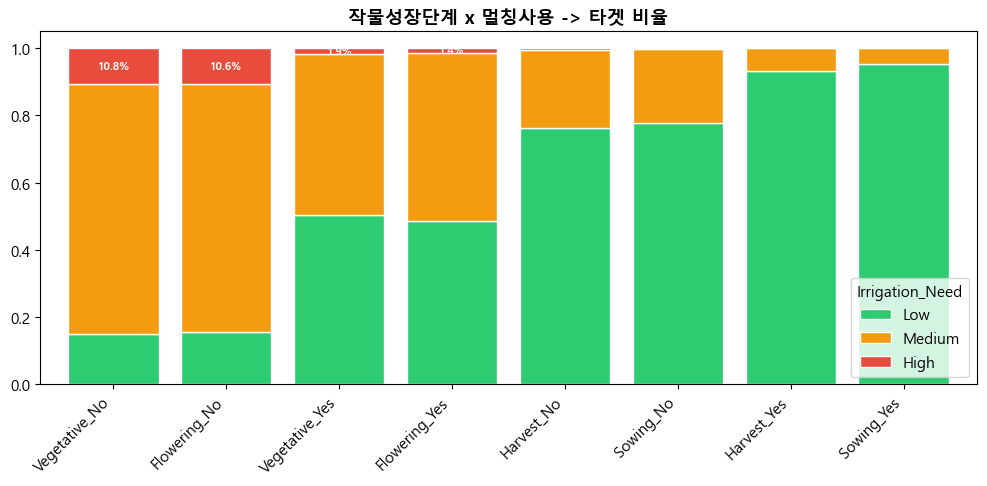

In [10]:
train['GrowthStage_Mulching'] = train['Crop_Growth_Stage'] + '_' + train['Mulching_Used']
ct = pd.crosstab(train['GrowthStage_Mulching'], train[TARGET], normalize='index')[['Low', 'Medium', 'High']]
ct = ct.sort_values('High', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ct.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#f39c12', '#e74c3c'],
        edgecolor='white', width=0.8)
ax.set_title('작물성장단계 x 멀칭사용 -> 타겟 비율', fontweight='bold')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylim(0, 1.05)
ax.legend(title='Irrigation_Need')

# High % 표시
for j, (idx, row) in enumerate(ct.iterrows()):
    if row['High'] > 0.01:
        ax.text(j, row['Low'] + row['Medium'] + row['High']/2, f"{row['High']:.1%}",
                ha='center', va='center', fontsize=8, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

train.drop('GrowthStage_Mulching', axis=1, inplace=True)

## 8. 요약

### 핵심 발견사항

| 항목 | 내용 |
|------|------|
| **타겟 불균형** | High=3.3%, Medium=37.9%, Low=58.7% -- Balanced Accuracy 평가이므로 High 클래스 예측이 점수에 큰 영향 |
| **수치형 핵심 피처** | `Soil_Moisture` (가장 강력), `Temperature_C`, `Rainfall_mm`, `Wind_Speed_kmh` |
| **범주형 핵심 피처** | `Crop_Growth_Stage` (가장 강력), `Mulching_Used` |
| **약한 피처** | `Organic_Carbon`, `Soil_pH`, `Sunlight_Hours`, `Field_Area_hectare`, `Previous_Irrigation_mm` -- 타겟 분리력 미미 |
| **피처 간 상관관계** | 강한 상관 없음 (다중공선성 문제 없음) |
| **Train/Test 분포** | 거의 동일 -- 분포 이동(distribution shift) 없음 |
| **결측치** | 없음 |

### 모델링 시사점
- **클래스 불균형 처리**가 핵심 (class_weight, oversampling, threshold tuning 등)
- **Crop_Growth_Stage**가 가장 강력한 피처 -- Harvest/Sowing은 85%+ Low로 편중
- **Mulching_Used=Yes**이면 73% Low로 예측
- 수치형/범주형 혼합 데이터 -> 트리 기반 모델 (LightGBM, XGBoost, CatBoost) 적합
- 피처 엔지니어링: 상위 피처 간 인터랙션 (Soil_Moisture x Temperature, Growth_Stage x Mulching 등)